# Kredi Kartı Dolandırıcılığı Tespiti

Önceki egzersizler, bir sinir ağının tüm farklı bileşenlerine daha yakından bakmanızı sağladı:
* sıralı (sequential) yoğun (Dense) bir Sinir Ağı mimarisi,
* derleme (compilation) yöntemi,
* modelin eğitilmesi (fitting).

Şimdi **çok fazla veri içeren** gerçek hayat bir veri seti üzerinde çalışalım!

**Veri seti: `Kredi Kartı İşlemleri (Credit Card Transactions)`**

Bu açık uçlu challenge’da, **kredi kartı işlemlerinden elde edilmiş verilerle** çalışacaksınız.

Bu veriler **hassas** olduğu için, toplam 31 sütundan yalnızca 3’ü bilinmektedir; geri kalanlar verileri **anonimleştirmek** amacıyla dönüştürülmüştür (aslında bunlar, orijinal verilerin **PCA projeksiyonlarıdır**).

Bilinen 3 sütun şunlardır:

* `TIME`: İşlemin, veri setindeki ilk işleme göre geçen süresi  
* `AMOUNT`: İşlem tutarı  
* `CLASS` (hedef değişkenimiz):
    * `0 : geçerli işlem`
    * `1 : sahte (fraud) işlem`

❓ **Soru** ❓ Veri setini indirerek başlayın:
* Kaggle üzerinden: [buradan](https://www.kaggle.com/mlg-ulb/creditcardfraud)
* veya bizim URL’mizden: [buradan](https://d32aokrjazspmn.cloudfront.net/materials/creditcard.csv)

Veriyi yükleyerek `X` ve `y` değişkenlerini oluşturun.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ~144 MB; ilk seferde indirip diske kaydediyoruz, sonraki çalıştırmalarda yerelden okunur
import os
CSV = "creditcard.csv"
URL = "https://d32aokrjazspmn.cloudfront.net/materials/creditcard.csv"
if not os.path.exists(CSV):
    pd.read_csv(URL).to_csv(CSV, index=False)

df = pd.read_csv(CSV)
X = df.drop(columns=["Class"])
y = df["Class"]

print(df.shape)
df.head()

2026-09-22 17:15:55.479921: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-22 17:15:55.491496: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-22 17:15:55.610462: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-22 17:15:55.723270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-22 17:15:55.848146: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Sınıfların yeniden dengelenmesi

In [2]:
# Sınıf dengesini kontrol edelim
pd.Series(y).value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

☝️ Bu `fraud detection` (sahtekârlık tespiti) challenge’ında **sınıflar aşırı derecede dengesizdir**:
* %99.8 normal işlemler
* %0.2 sahte (fraud) işlemler

**Ciddi yeniden dengeleme (rebalancing) stratejileri uygulamazsak sahtekârlık vakalarını tespit edemeyiz!**

❓ **Soru** ❓
1. **Önce**, veri setinizden üç ayrı bölme oluşturun: `Train / Val / Test`.  
   Doğrulama (validation) ve test setlerinin **dengesiz** kalması son derece önemlidir; böylece modeli değerlendirirken gerçek koşullar korunur ve veri sızıntısı (data leakage) oluşmaz. Test setinizi bu notebook’un **en son hücresine kadar saklayın**!

&nbsp;

2. **İkinci olarak**, yalnızca eğitim setinizi (training set) yeniden dengeleyin. Birçok seçeneğiniz var:

- Azınlık sınıfını rastgele oversample etmek (düz NumPy fonksiyonlarıyla).  
  *(En iyi seçenek değildir; çünkü satırları kopyalayarak veri sızıntısı yaratır.)*
- <a href="https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/">**`Synthetic Minority Oversampling Technique - SMOTE`**</a> kullanarak, mevcut gözlemleri ağırlıklandırıp yeni veri noktaları üretmek
- Buna ek olarak, çoğunluk sınıfını bir miktar küçültmek için  
  <a href="https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/">**`RandomUnderSampler`**</a> da deneyebilirsiniz

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1) Train / Val / Test — val ve test DENGESİZ kalıyor (gerçek koşullar + test kuralı)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.2, stratify=y_tmp, random_state=SEED)

print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
print(f"test fraud={(y_test == 1).sum()}  non-fraud={(y_test == 0).sum()}"
      f"  oran=1:{(y_test == 0).sum() // (y_test == 1).sum()}")

# 2) Ölçekleme — scaler SADECE train'e fit ediliyor (val/test'e sızıntı olmasın)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# 3) Yeniden dengeleme SADECE train'e uygulanıyor
#    sampling_strategy=0.1 -> azınlık, çoğunluğun %10'una çıkarılıyor.
#    Tam 1:1 yapmıyoruz: aşırı sentetik veri precision'ı çökertiyor.
sm = SMOTE(sampling_strategy=0.1, random_state=SEED)
X_train_r, y_train_r = sm.fit_resample(X_train_s, y_train)

print(f"SMOTE sonrası train={len(X_train_r)}  fraud={int(y_train_r.sum())}")

train=182276  val=45569  test=56962
test fraud=98  non-fraud=56864  oran=1:580
SMOTE sonrası train=200157  fraud=18196


## 2. Sinir Ağı yinelemeleri

Sınıflarınızı yeniden dengelediğinize göre, test puanınızı optimize etmek için bir sinir ağı uyarlayın. Aşağıdaki ipuçlarını kullanmaktan çekinmeyin:

- Girişlerinizi normalleştirin!
    - Modelinizdeki ön işlemeyi “boru hattı” haline getirmek için tercihen model içinde bir [`Normalization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization) katmanı kullanın. 
    - Veya modelinizin dışında sklearn'in [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) öğesini kullanın, `X_train`, `X_val` ve `X_test` öğelerini uygulayın.
- Modelinizi aşırı uyumlu hale getirin, ardından aşağıdakileri kullanarak düzenleyin:
- Erken Durdurma kriterleri
- [`Dropout`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) katmanları
    - veya [`düzenleyiciler`](https://www.tensorflow.org/api_docs/python/tf/keras/regularizers) katmanları
- 🚨 İzlemek istediğiniz metrikleri ve kullanmak istediğiniz kayıp fonksiyonunu dikkatlice düşünün!

In [4]:
from tensorflow.keras import Sequential, layers, callbacks, metrics

model = Sequential([
    layers.Input(shape=(X_train_r.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

# accuracy burada işe yaramaz: hep 0 tahmin eden model %99.8 accuracy alır.
# PR-AUC dengesiz veride doğru özet metrik.
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=[metrics.Precision(name="precision"),
             metrics.Recall(name="recall"),
             metrics.AUC(curve="PR", name="pr_auc")],
)

es = callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                             patience=5, restore_best_weights=True)

history = model.fit(
    X_train_r, y_train_r,
    validation_data=(X_val_s, y_val),   # doğrulama seti dengesiz kalıyor
    epochs=40, batch_size=1024,
    callbacks=[es], verbose=0)

print(f"Durduğu epoch: {es.stopped_epoch or len(history.history['loss'])}")
model.summary()

Durduğu epoch: 6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,613 (18.02 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,076 (12.02 KB)

### 🧪 Kodunu Test Et

Orijinal dengesiz veri kümesinin (`X_test`, `y_test`) temsil edici bir örneğinde gerçek test performansınızın altında kalan sonuçları `precision` ve `recall` değişkenlerine kaydedin.

Seçilen eşik: 0.8016 (val precision=0.821, val recall=0.810)

TEST  precision=0.703   recall=0.847

Confusion matrix:
 [[56829    35]
 [   15    83]]


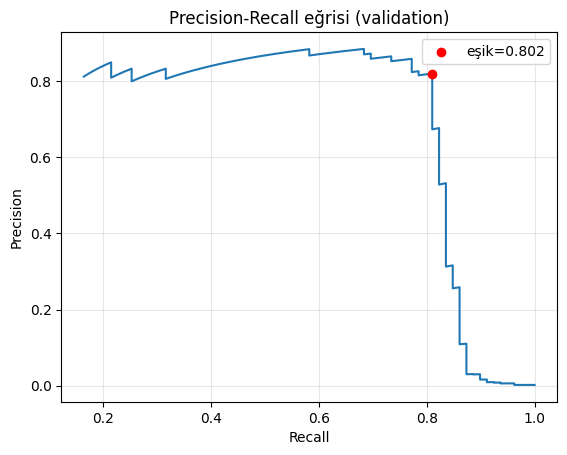

In [5]:
from sklearn.metrics import (precision_recall_curve, precision_score,
                             recall_score, confusion_matrix)
import matplotlib.pyplot as plt

# Eşiği VALIDATION üzerinde seçiyoruz; test setine hiç bakmıyoruz.
val_proba = model.predict(X_val_s, verbose=0).ravel()
prec, rec, thr = precision_recall_curve(y_val, val_proba)
prec, rec = prec[:-1], rec[:-1]
f1 = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)

TARGET_RECALL = 0.80
ok = rec >= TARGET_RECALL
best_thr = float(thr[ok][np.argmax(f1[ok])]) if ok.any() else float(thr[np.argmax(f1)])
i = int(np.argmin(np.abs(thr - best_thr)))
print(f"Seçilen eşik: {best_thr:.4f} "
      f"(val precision={prec[i]:.3f}, val recall={rec[i]:.3f})")

# Nihai değerlendirme: dokunulmamış, dengesiz TEST seti
y_pred = (model.predict(X_test_s, verbose=0).ravel() >= best_thr).astype(int)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"\nTEST  precision={precision:.3f}   recall={recall:.3f}")
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

plt.plot(rec, prec)
plt.scatter(rec[i], prec[i], color="red", zorder=5, label=f"eşik={best_thr:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall eğrisi (validation)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [6]:
from nbresult import ChallengeResult

result = ChallengeResult('solution',
    precision=precision,
    recall=recall,
    fraud_number=len(y_test[y_test == 1]),
    non_fraud_number=len(y_test[y_test == 0]),
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/lemfi/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/lemfi/projects/S18D3-S-Data-credit-card-challenge/tests
plugins: dash-4.3.0, typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_solution.py::TestSolution::test_is_score_good_enough PASSED         [ 50%]
test_solution.py::TestSolution::test_is_test_set_representative PASSED   [100%]

============================== 2 passed in 0.05s ===============================


💯 You can commit your code:

git add tests/solution.pickle

git commit -m 'Completed solution step'

git push origin master



## 🏁 İsteğe bağlı: Bu zorluk için Google'ın çözümünü okuyun
Bu oturumdaki tüm zorlukları tamamladığınız için tebrikler!

Son olarak, Google'ın kendi çözümünü doğrudan [Colab'da buradan](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/structured_data/imbalanced_data.ipynb) okuyun. 

İlginç teknikler ve en iyi uygulamaları keşfedeceksiniz.